In [1]:
import pandas as pd
df = pd.read_csv('ecommerce_customer_data_large.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ecommerce_customer_data_large.csv'

## Recommendations

1. Offer loyalty rewards and exclusive perks to High Value customers to strengthen retention and encourage referrals.
2. Launch targeted discount or win-back campaigns for At Risk customers to prevent churn before they become inactive.
3. Send personalized re-engagement emails or surveys to Lost customers to understand why they stopped purchasing.
4. Use segment-specific marketing communication instead of one-size-fits-all messaging to improve engagement rates.
5. Investigate product categories with higher return rates and improve product descriptions/quality checks to reduce returns and boost customer satisfaction.

In [2]:
import pandas as pd
df = pd.read_csv('/ecommerce_customer_data_large.csv')
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [4]:
df['Returns'] = df['Returns'].fillna(0)

df = df.drop_duplicates()

df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,0
Customer Name,0


In [5]:
import pandas as pd

df['Purchase Date'] = pd.to_dayetime(df['Purchase Date'])

reference_date = df['Purchase Date'].max()+pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Purchase Date',lambda x:(reference_date-x.max()).days),
    Frequency=('Purchase Date','count'),
    Monetary=('Total Purchase Amount','sum')
).reset_index()

rfm.head()

AttributeError: module 'pandas' has no attribute 'to_dayetime'

In [6]:
import pandas as pd

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

reference_date = df['Purchase Date'].max()+pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Purchase Date',lambda x:(reference_date-x.max()).days),
    Frequency=('Purchase Date','count'),
    Monetary=('Total Purchase Amount','sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,1,289,3,6290
1,2,73,6,16481
2,3,223,4,9423
3,4,442,5,7826
4,5,425,5,9769


In [7]:
# Har metric ko 1-4 score do (quartiles ke basis pe)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

def segment(score):
    if score >= 10:
        return 'High Value'
    elif score >= 7:
        return 'Loyal'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,1,289,3,6290,2,1,1,4,At Risk
1,2,73,6,16481,4,3,3,10,High Value
2,3,223,4,9423,2,2,2,6,At Risk
3,4,442,5,7826,1,2,1,4,At Risk
4,5,425,5,9769,1,2,2,5,At Risk
5,6,141,9,25428,3,4,4,11,High Value
6,7,142,8,17825,3,4,3,10,High Value
7,8,26,7,16245,4,4,3,11,High Value
8,9,141,7,24621,3,4,4,11,High Value
9,10,131,8,20672,3,4,4,11,High Value


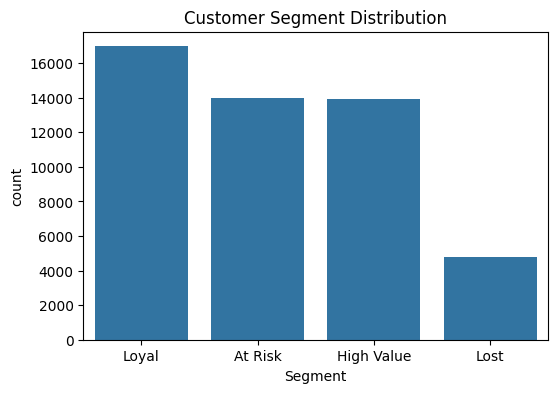

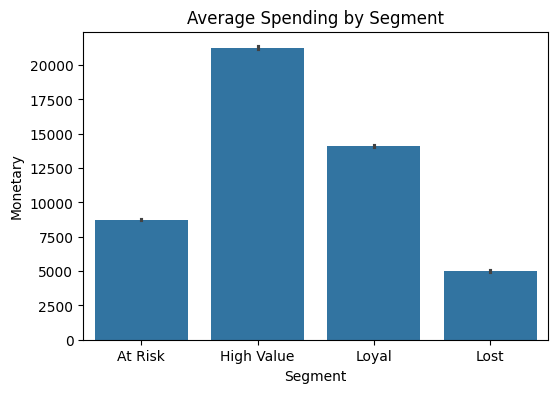

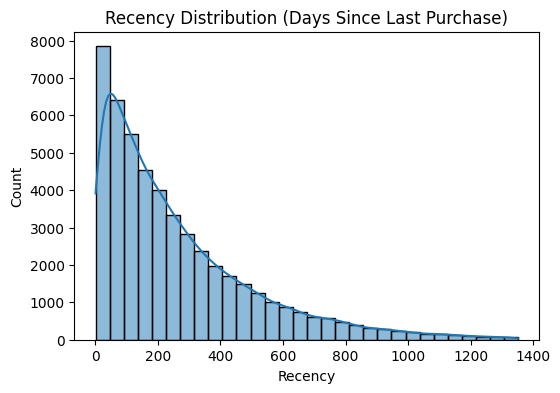

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Segment distribution
plt.figure(figsize=(6,4))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)
plt.title('Customer Segment Distribution')
plt.show()

# Segment-wise average spending
plt.figure(figsize=(6,4))
sns.barplot(data=rfm, x='Segment', y='Monetary', estimator='mean')
plt.title('Average Spending by Segment')
plt.show()

# Recency distribution
plt.figure(figsize=(6,4))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Recency Distribution (Days Since Last Purchase)')
plt.show()